# Final results — recomb sweep at cov 10×, **v3 panel — ARMS ONLY (centromere excluded)**

**Created 2026-05-10.** Same framework as `FINAL_RESULTS_cov10_v3.ipynb` but with **Chr1 centromere positions 14,000,000 – 17,000,000 excluded** from all panels.

**Why filter the centromere?** A regional deep-dive on the v3 panel showed that v3's R² drop vs v2 (e.g. cactus_em ★★ from 0.995 → 0.960) is **dominated by centromeric records**:

| region | v2 ★★ R² | v3 ★★ R² | drop |
|---|---|---|---|
| p arm (1-14 Mb) | 0.996 | **0.982** | -0.014 |
| **centromere (14-17 Mb)** | **0.993** | **0.782** | **-0.211** |
| q arm (17-30 Mb) | 0.995 | 0.977 | -0.018 |

Beagle imputation in v2 smoothed over the centromere's k-mer ambiguity, repeat-region uncertainty, and patchy cactus founder genotyping. v3 keeps all the raw signal, which causes systematic mosaic-underestimation in the centromere core (worst at Mb 15: R²=0.65). Outside the centromere, v3 cactus_em is essentially v2-quality (~0.98). This notebook strips the centromere to show what cactus_em achieves on the records we trust quantitatively.

**Same framework as the parent notebook** (5 methods, 3 regimes, full hexbins / R² tables / 3-way hapFIRE breakdown), just with `pos < 14_000_000 OR pos >= 17_000_000` applied to the polymorphic record set.

## The 5 methods — 3-way hapFIRE diagnostic isolates panel vs projection vs method

| method | what it is | scale |
|---|---|---|
| **freqk-v3** | k-mer counting per panel SV bubble, no founder model — re-indexed on a **no-missing** v3 source VCF (`founders_231_chr.haploid.no_missing.vcf.gz`, `.`→`0/0`) | per-record |
| **cactus_em-v3 global** | k-mer Poisson EM on the v3 panel, single chrom-wide `h` (no window/anchor/smooth) | whole chrom |
| **hapfire-v2panel-v3proj** ◇ | hapFIRE on the v2 GrENE-Net SNP catalog, then output projected through `cn_var_231_v3` so it's row-aligned to truth_v3 — isolates the **projection switch** from the panel switch | 10 kb |
| **hapfire-v3panel** ★ | hapFIRE on the v3 SNP-only Chr1 panel, fake-phased homozygous-diploid carrier-status — isolates the **full v3-panel switch** | 10 kb |
| **cactus_em-v3 window+λ+smooth** ★★ | cactus_em on v3 panel: window-mode @ 10 kb + Dirichlet anchor toward `h_global` + post-EM Li-Stephens HMM smoothing — **production recipe** | **10 kb** |

★★ Production recipe: `--block-mode window --window-bp 10000 --global-anchor-weight 0.3 --hmm-smooth-passes 5 --hmm-smooth-alpha 0.5`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.cm as cm

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')
SIMS = ROOT / 'sims/visor_freqk'

REGIMES = {
    'n200_g1_cov10':       SIMS / 'pool_sweep_82_recomb' / 'cov10_n200_g1_s42_hotspots_p231_chr1',
    'n50_g1_cov10':        SIMS / 'pool_sweep_82_recomb' / 'cov10_n50_g1_s42_hotspots_p231_chr1',
    'n50_g3_cov10':        SIMS / 'pool_sweep_82_recomb' / 'cov10_n50_g3_s42_hotspots_p231_chr1',
    'n50_g3_skewed_cov10': SIMS / 'pool_sweep_82_recomb_skewed' / 'cov10_n50_g3_s42_hotspots_dom500_p231_chr1',
}
REGIME_LABELS = {
    'n200_g1_cov10':       'n200_g1\n(easy)',
    'n50_g1_cov10':        'n50_g1\n(med)',
    'n50_g3_cov10':        'n50_g3\n(hard, mosaic)',
    'n50_g3_skewed_cov10': 'n50_g3 skewed\n(dom500, stress)',
}

# 'rowidx' methods are row-aligned to cn_var_v3 (TSV row k <-> truth row k).
# 'freqk' joins by (chrom, pos+2, alt_len) -- freqk reports VCF_pos - 2 per
# the feedback memory; we add 2 before merging.
METHODS = ['freqk', 'global', 'hapfire_v2panel_v3proj', 'hapfire_v3panel', 'window_10kb_smooth']
METHOD_FILES = {
    'freqk':                  ('chrompos', 'freqk_v3_per_record.tsv.gz'),
    'global':                 ('rowidx',   'cactus_em_recomb_GLOBAL_v3.tsv'),
    'hapfire_v2panel_v3proj': ('rowidx',   'hapfire_v2panel_v3proj_win10kb_perblock_proj.tsv'),
    'hapfire_v3panel':        ('rowidx',   'hapfire_v3_win10kb_perblock_proj.tsv'),
    'window_10kb_smooth':     ('rowidx',   'cactus_em_recomb_window_10kb_anchor0.3_smooth5a05_v3.tsv'),
}
METHOD_LABELS = {
    'freqk':                  'freqk-v3 (key=ref/alt)',
    'global':                 'cactus_em-v3 global',
    'hapfire_v2panel_v3proj': 'hapfire v2-panel + v3-proj ◇',
    'hapfire_v3panel':        'hapfire v3-panel ★',
    'window_10kb_smooth':     'cactus_em-v3 10kb + λ=0.3 + smooth ★★',
}

# Sidecar: row-aligned (chrom, pos, ref, alt) for cn_var_v3, joining freqk by alt.
# Built once via `bcftools query -f '%CHROM\t%POS\t%REF\t%ALT\n' founders_231_chr.haploid.vcf.gz`.
# We merge freqk on (chrom, pos, alt) — NOT (chrom, pos, ref, alt) — because
# freqk's REF is the bubble multi-base string while truth's REF is the per-variant
# REF (single char for SNPs). The ALT character matches between the two for SNPs
# (and for the subset of SVs whose freqk-bubble-ALT happens to equal the VCF-atomized-ALT).
REF_ALT_SIDECAR = ROOT / 'poolfreq/data/cn_var_231_v3.ref_alt.tsv.gz'
ref_alt = pd.read_csv(REF_ALT_SIDECAR, sep='\t', header=None, names=['chrom','pos','ref','alt'])


def load_regime(work: Path) -> pd.DataFrame:
    truth = pd.read_csv(work / 'recomb_truth_v3.tsv.gz', sep='\t', compression='gzip')
    base = truth[['chrom', 'pos', 'ref_len', 'alt_len', 'truth_af']].copy()
    n = len(base)
    if len(ref_alt) != n:
        print(f'WARN: ref_alt sidecar rows {len(ref_alt):,} != truth rows {n:,}')
    base['alt'] = ref_alt['alt'].to_numpy()
    for m in METHODS:
        join_kind, fname = METHOD_FILES[m]
        f = work / fname
        if not f.exists():
            print(f'  {m:<28s} MISSING ({fname})')
            base[m] = np.nan
            continue
        if join_kind == 'rowidx':
            df = pd.read_csv(f, sep='\t')
            if len(df) != n:
                print(f'  {m:<28s} ROW MISMATCH: {len(df)} vs cn_var_v3 {n}')
                base[m] = np.nan
                continue
            base[m] = df['alt_freq'].astype(np.float32).to_numpy()
        elif join_kind == 'chrompos':
            df = pd.read_csv(f, sep='\t')
            af_col = 'freqk_af' if 'freqk_af' in df.columns else 'alt_freq'
            # freqk reports VCF_pos - 2; correct first.
            df['pos'] = df['pos'].astype(np.int64) + 2
            # Restrict to Chr1: sims are Chr1-only but freqk indexes the full VCF;
            # cross-chrom k-mer collisions otherwise leak ~10k spurious "predictions"
            # into the Chr2-5 record set, which the other (read-driven) methods
            # don't produce. Apples-to-apples requires Chr1-only freqk.
            df = df[df.chrom == 'Chr1']
            # Merge on (chrom, pos, alt). Critical: drop ref because freqk's ref
            # is the bubble (multi-base), VCF's is the per-variant REF. ALT char
            # matches for SNPs and atomization-aligned SV ALTs. Without alt in
            # the key, distinct ALTs at the same pos collapse to mean=0.5.
            df = df[['chrom', 'pos', 'alt', af_col]].rename(columns={af_col: m})
            base = base.merge(df, on=['chrom', 'pos', 'alt'], how='left')
    base['var_type'] = np.where(
        (base.ref_len == 1) & (base.alt_len == 1), 'SNP',
        np.where(base.alt_len > base.ref_len, 'INS',
                 np.where(base.ref_len > base.alt_len, 'DEL', 'COMPLEX')))
    return base


regime_data = {}
for r, work in REGIMES.items():
    print(f'Loading {r}...')
    regime_data[r] = load_regime(work)

# Centromere filter — exclude Chr1 14-17 Mb (where R² collapses to 0.65-0.85).
# Other chroms are kept as-is (no sims there, but doesn't hurt to keep the rows
# since methods will be NaN there and dropped by the metrics filter).
CENTROMERE_BAND = ('Chr1', 14_000_000, 17_000_000)

for r in regime_data:
    df = regime_data[r]
    poly_mask = (df.truth_af > 0) & (df.truth_af < 1)
    centromere_mask = ((df.chrom == CENTROMERE_BAND[0]) &
                       (df.pos >= CENTROMERE_BAND[1]) &
                       (df.pos <  CENTROMERE_BAND[2]))
    n_before = poly_mask.sum()
    n_centromere = (poly_mask & centromere_mask).sum()
    print(f'  {r}: {n_before:>10,} polymorphic  -  {n_centromere:>8,} centromere  =  {n_before - n_centromere:>10,} arms-only')
    regime_data[r] = df[poly_mask & ~centromere_mask].copy()

print('\nPer-regime polymorphic record count:')
for r, df in regime_data.items():
    print(f'  {r:<16s}  total={len(df):>9,}  SNP={(df.var_type=="SNP").sum():>8,}  '
          f'INS={(df.var_type=="INS").sum():>7,}  DEL={(df.var_type=="DEL").sum():>7,}')

print('\nPer-method polymorphic-with-pred count (not-NaN), n50_g3:')
df = regime_data['n50_g3_cov10']
for m in METHODS:
    print(f'  {m:<28s}  n_pred={int(df[m].notna().sum()):>8,}')

Loading n200_g1_cov10...


Loading n50_g1_cov10...


Loading n50_g3_cov10...


Loading n50_g3_skewed_cov10...


  n200_g1_cov10:  4,587,288 polymorphic  -    86,130 centromere  =   4,501,158 arms-only


...


Per-regime polymorphic record count:


  n200_g1_cov10     total=4,501,158  SNP=2,335,232  INS=585,021  DEL=612,435


  n50_g1_cov10      total=3,073,959  SNP=1,618,547  INS=369,427  DEL=437,910


  n50_g3_cov10      total=2,666,041  SNP=1,414,249  INS=315,302  DEL=378,757


  n50_g3_skewed_cov10  total=2,666,041  SNP=1,414,249  INS=315,302  DEL=378,757

Per-method polymorphic-with-pred count (not-NaN), n50_g3:
  freqk                         n_pred= 126,863
  global                        n_pred= 621,002
  hapfire_v2panel_v3proj        n_pred= 603,616
  hapfire_v3panel               n_pred= 617,291
  window_10kb_smooth            n_pred= 621,002


## Headline R² table

Per-record alt-AF R² vs truth_v3 on Chr1 polymorphic records, by `var_type` and regime. Higher = better. Best per (regime, var_type) cell highlighted by green-on-RdYlGn gradient.

In [2]:
def metrics(t: np.ndarray, p: np.ndarray) -> dict:
    f = np.isfinite(t) & np.isfinite(p)
    t, p = t[f], p[f]
    if len(t) < 5 or t.std() == 0 or p.std() == 0:
        return dict(n=int(len(t)), R2=np.nan, MAE=np.nan, slope=np.nan)
    err = p - t
    r = np.corrcoef(t, p)[0, 1]
    slope = np.polyfit(t, p, 1)[0]
    return dict(n=int(len(t)), R2=float(r * r),
                MAE=float(np.mean(np.abs(err))), slope=float(slope))


rows = []
for r, df in regime_data.items():
    for vt in ['SNP', 'INS', 'DEL']:
        sub = df[df.var_type == vt]
        for m in METHODS:
            mres = metrics(sub.truth_af.to_numpy(), sub[m].to_numpy())
            rows.append({'regime': r, 'var_type': vt, 'method': m, **mres})
summary = pd.DataFrame(rows)

headline = summary.pivot_table(index='regime', columns=['method', 'var_type'], values='R2')
headline = headline.reindex(list(REGIMES.keys()))
headline = headline.reindex(
    columns=pd.MultiIndex.from_product([METHODS, ['SNP', 'INS', 'DEL']],
                                        names=['method', 'var_type']))
headline.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}', na_rep='—')

## hapFIRE 3-way breakdown — where is the accuracy leaking?

Three configs share method (hapFIRE @ 10 kb fixed-window) but differ in panel/projection:

| config | panel | projection | what it isolates |
|---|---|---|---|
| **v2-panel + v2-proj** | v2 GrENE-Net (clean baseline) | `cn_var_231_v2` | original baseline |
| **v2-panel + v3-proj** ◇ | v2 GrENE-Net (clean baseline) | `cn_var_231_v3` | pure projection switch |
| **v3-panel + v3-proj** ★ | v3 fake-phased + dedup'd | `cn_var_231_v3` | full v3 path |

The Δ between cells localizes whether accuracy lives in the panel switch or the projection switch.

In [3]:
# 3-way breakdown: SNP-only (hapFIRE structurally can't do SVs). Centromere excluded.
V2_TRUTH_FILE = 'recomb_truth.tsv.gz'
V2_HF_FILE    = 'hapfire_win10kb_perblock_proj.tsv'

three_way_rows = []
for r, work in REGIMES.items():
    if (work / V2_TRUTH_FILE).exists() and (work / V2_HF_FILE).exists():
        truth_v2 = pd.read_csv(work / V2_TRUTH_FILE, sep='\t', compression='gzip')
        hf_v2 = pd.read_csv(work / V2_HF_FILE, sep='\t')
        if len(hf_v2) == len(truth_v2):
            non_cent = ~((truth_v2.chrom == CENTROMERE_BAND[0]) &
                          (truth_v2.pos >= CENTROMERE_BAND[1]) &
                          (truth_v2.pos <  CENTROMERE_BAND[2]))
            mask = (truth_v2.truth_af > 0) & (truth_v2.truth_af < 1) & (truth_v2.ref_len == 1) & (truth_v2.alt_len == 1) & non_cent
            mres = metrics(truth_v2.truth_af[mask].to_numpy(),
                           hf_v2['alt_freq'].astype(np.float32)[mask].to_numpy())
            three_way_rows.append({'regime': r, 'config': '(a) v2-panel + v2-proj', **mres})
    df = regime_data[r]
    sub = df[df.var_type == 'SNP']
    mres = metrics(sub.truth_af.to_numpy(), sub['hapfire_v2panel_v3proj'].to_numpy())
    three_way_rows.append({'regime': r, 'config': '(b) v2-panel + v3-proj ◇', **mres})
    mres = metrics(sub.truth_af.to_numpy(), sub['hapfire_v3panel'].to_numpy())
    three_way_rows.append({'regime': r, 'config': '(c) v3-panel + v3-proj ★', **mres})

three_way = pd.DataFrame(three_way_rows)
pivot = three_way.pivot_table(index='regime', columns='config', values='R2').reindex(list(REGIMES.keys()))
print(pivot.round(3))
print()

a_col = [c for c in pivot.columns if c.startswith('(a)')][0]
b_col = [c for c in pivot.columns if c.startswith('(b)')][0]
c_col = [c for c in pivot.columns if c.startswith('(c)')][0]
print('Delta projection (b - a):', [round(pivot.loc[r, b_col] - pivot.loc[r, a_col], 3) for r in REGIMES])
print('Delta panel      (c - b):', [round(pivot.loc[r, c_col] - pivot.loc[r, b_col], 3) for r in REGIMES])

pivot.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.3f}', na_rep='—')

config               (a) v2-panel + v2-proj  (b) v2-panel + v3-proj ◇  \
regime                                                                  
n200_g1_cov10                         0.874                     0.887   
n50_g1_cov10                          0.805                     0.814   
n50_g3_cov10                          0.718                     0.728   
n50_g3_skewed_cov10                   0.609                     0.619   

config               (c) v3-panel + v3-proj ★  
regime                                         
n200_g1_cov10                           0.898  
n50_g1_cov10                            0.827  
n50_g3_cov10                            0.725  
n50_g3_skewed_cov10                     0.604  

Delta projection (b - a): [0.013, 0.009, 0.009, 0.01]
Delta panel      (c - b): [0.011, 0.012, -0.002, -0.014]


config,(a) v2-panel + v2-proj,(b) v2-panel + v3-proj ◇,(c) v3-panel + v3-proj ★
regime,,,
n200_g1_cov10,0.874,0.887,0.898
n50_g1_cov10,0.805,0.814,0.827
n50_g3_cov10,0.718,0.728,0.725
n50_g3_skewed_cov10,0.609,0.619,0.604


## SNP — truth-vs-estimate hexbin grid

Each row = method, each column = regime. Diagonal `y = x` is the reference. Color = log-density of records in that bin. Cell label gives R², slope, MAE, and number of polymorphic records.

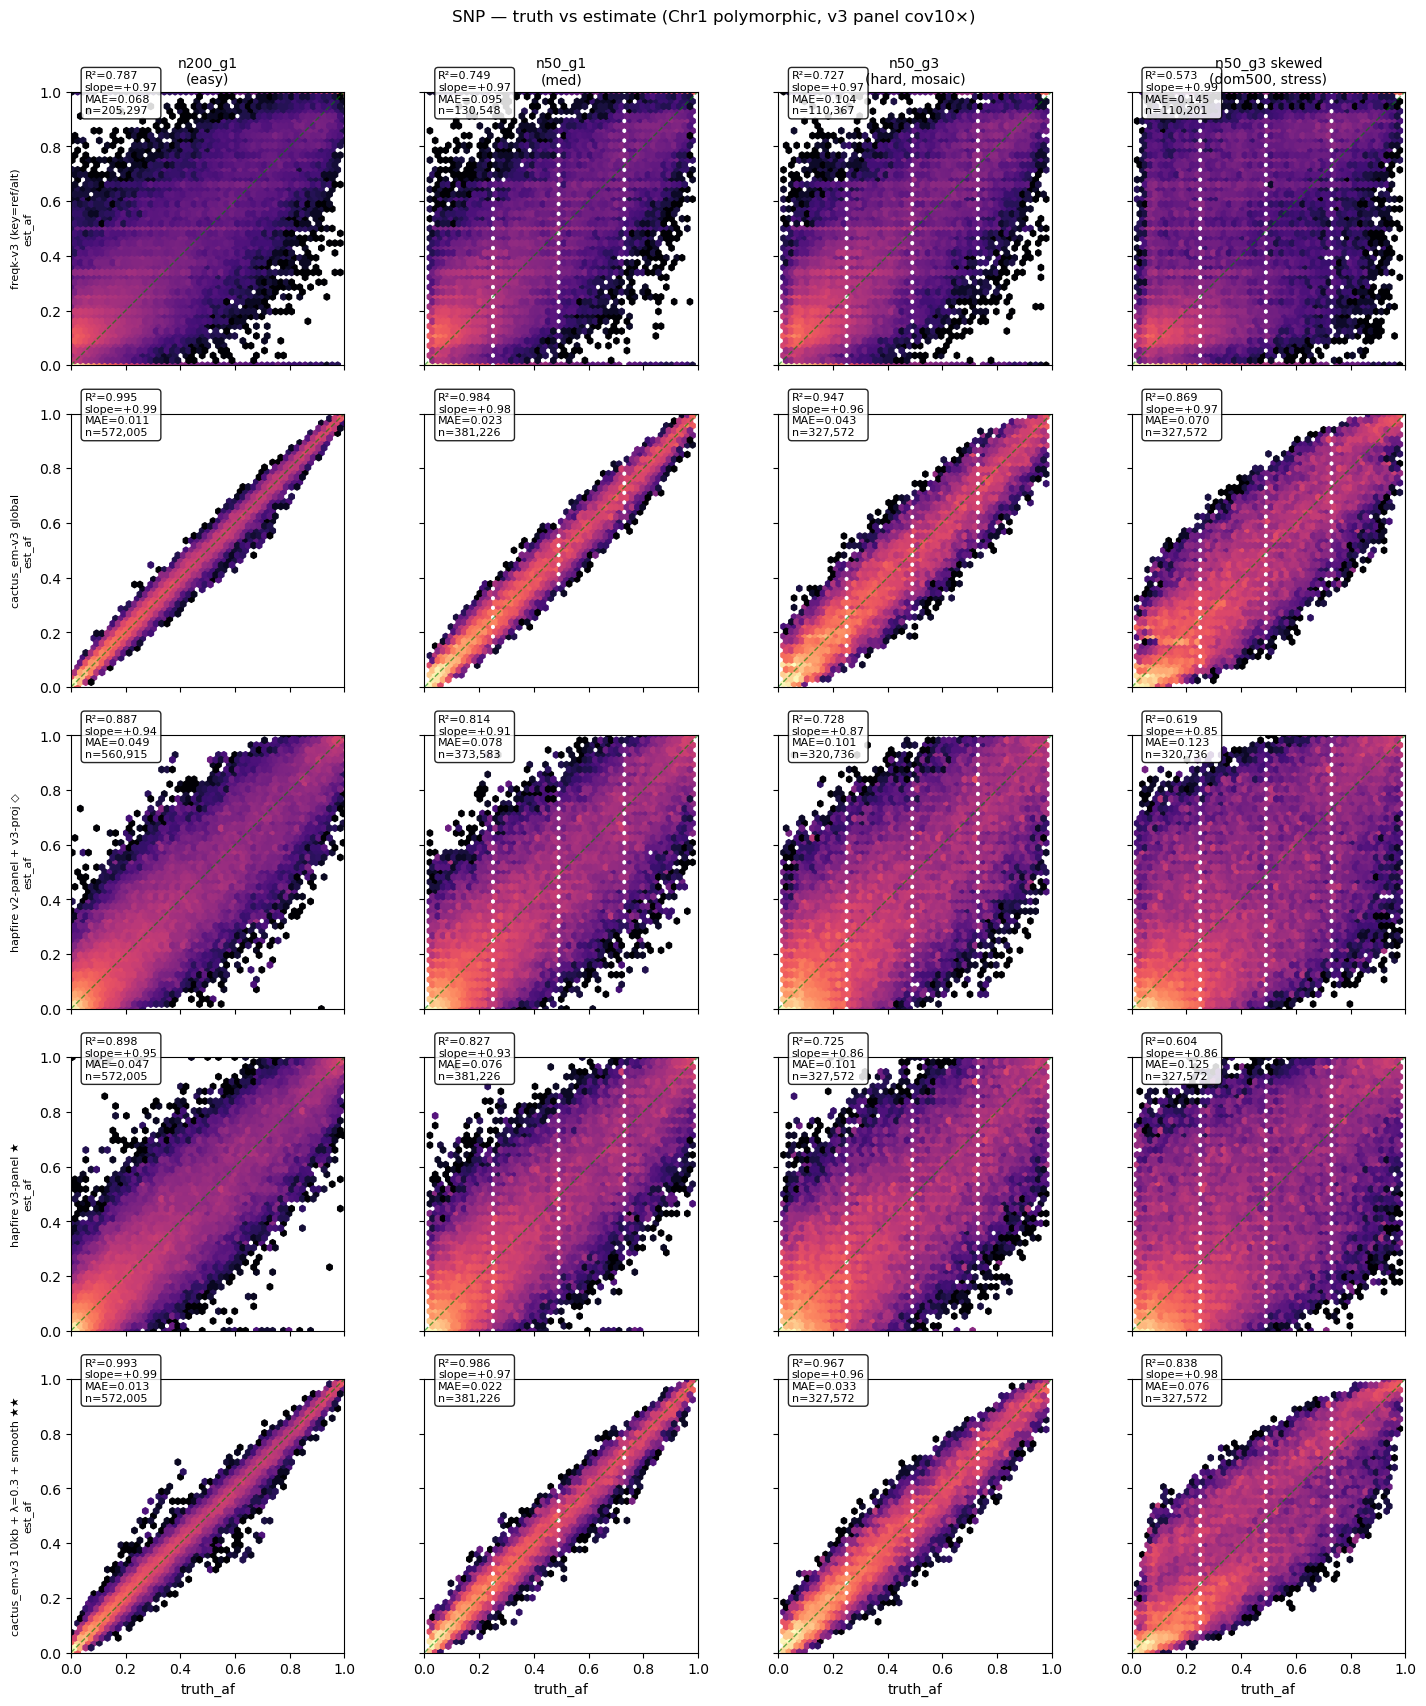

In [4]:
def hexgrid(var_filter, title, min_size=None):
    fig, axes = plt.subplots(len(METHODS), len(REGIMES),
                              figsize=(3.7 * len(REGIMES), 3.4 * len(METHODS)),
                              sharex=True, sharey=True)
    for i, m in enumerate(METHODS):
        for j, r in enumerate(REGIMES):
            ax = axes[i, j]
            ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
            if i == 0: ax.set_title(REGIME_LABELS[r], fontsize=10)
            if j == 0: ax.set_ylabel(f'{METHOD_LABELS[m]}\nest_af', fontsize=8)
            if i == len(METHODS) - 1: ax.set_xlabel('truth_af')
            df = regime_data[r]
            sub = df[var_filter(df)]
            if min_size is not None:
                sub = sub[(sub.ref_len - sub.alt_len).abs() >= min_size]
            sub = sub.dropna(subset=[m])
            if len(sub) < 5:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=10, color='gray')
                continue
            ax.hexbin(sub.truth_af, sub[m], gridsize=50, cmap='magma',
                      norm=LogNorm(), mincnt=1)
            ax.plot([0, 1], [0, 1], 'g--', lw=1, alpha=0.6)
            mres = metrics(sub.truth_af.to_numpy(), sub[m].to_numpy())
            label = (f"R²={mres['R2']:.3f}\nslope={mres['slope']:+.2f}\n"
                     f"MAE={mres['MAE']:.3f}\nn={mres['n']:,}") if not np.isnan(mres['R2']) else 'no data'
            ax.text(0.05, 0.92, label,
                    transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    fig.suptitle(title, y=1.001)
    fig.tight_layout(); plt.show()


hexgrid(lambda d: d.var_type == 'SNP',
        'SNP — truth vs estimate (Chr1 polymorphic, v3 panel cov10×)')

## Big insertions (≥50 bp)

hapFIRE rows show degraded R² on big-INS — hapFIRE is per-base SNP-only by construction; the SV signal in the projector comes from the founder × cn_var_v3 matrix mapping each window's `h` onto SV records. cactus_em rows show the full v3 INS coverage. (freqk-v3 still misbehaves — see Bottom line.)

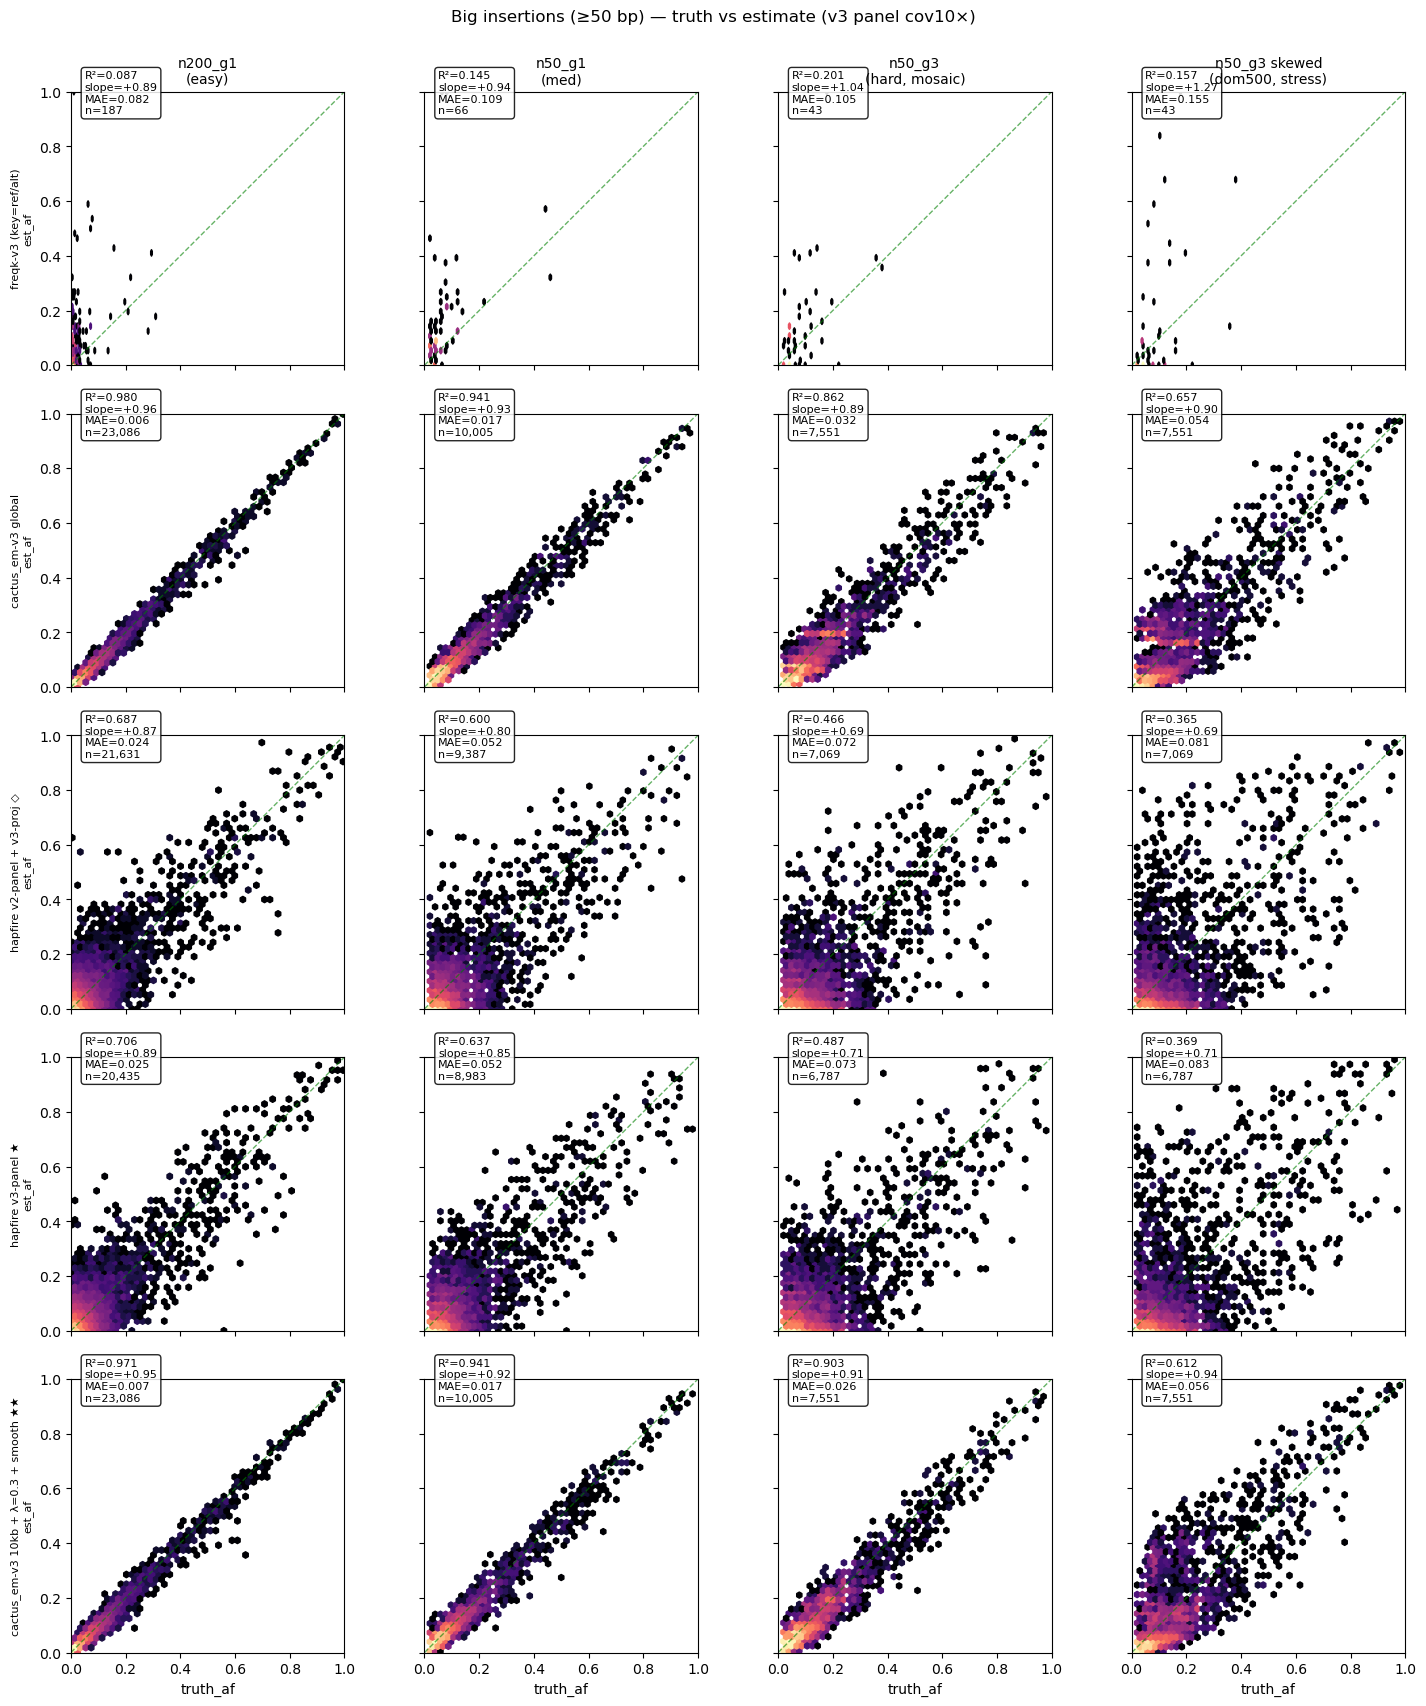

In [5]:
hexgrid(lambda d: d.var_type == 'INS',
        'Big insertions (≥50 bp) — truth vs estimate (v3 panel cov10×)',
        min_size=50)

## Big deletions (≥50 bp)

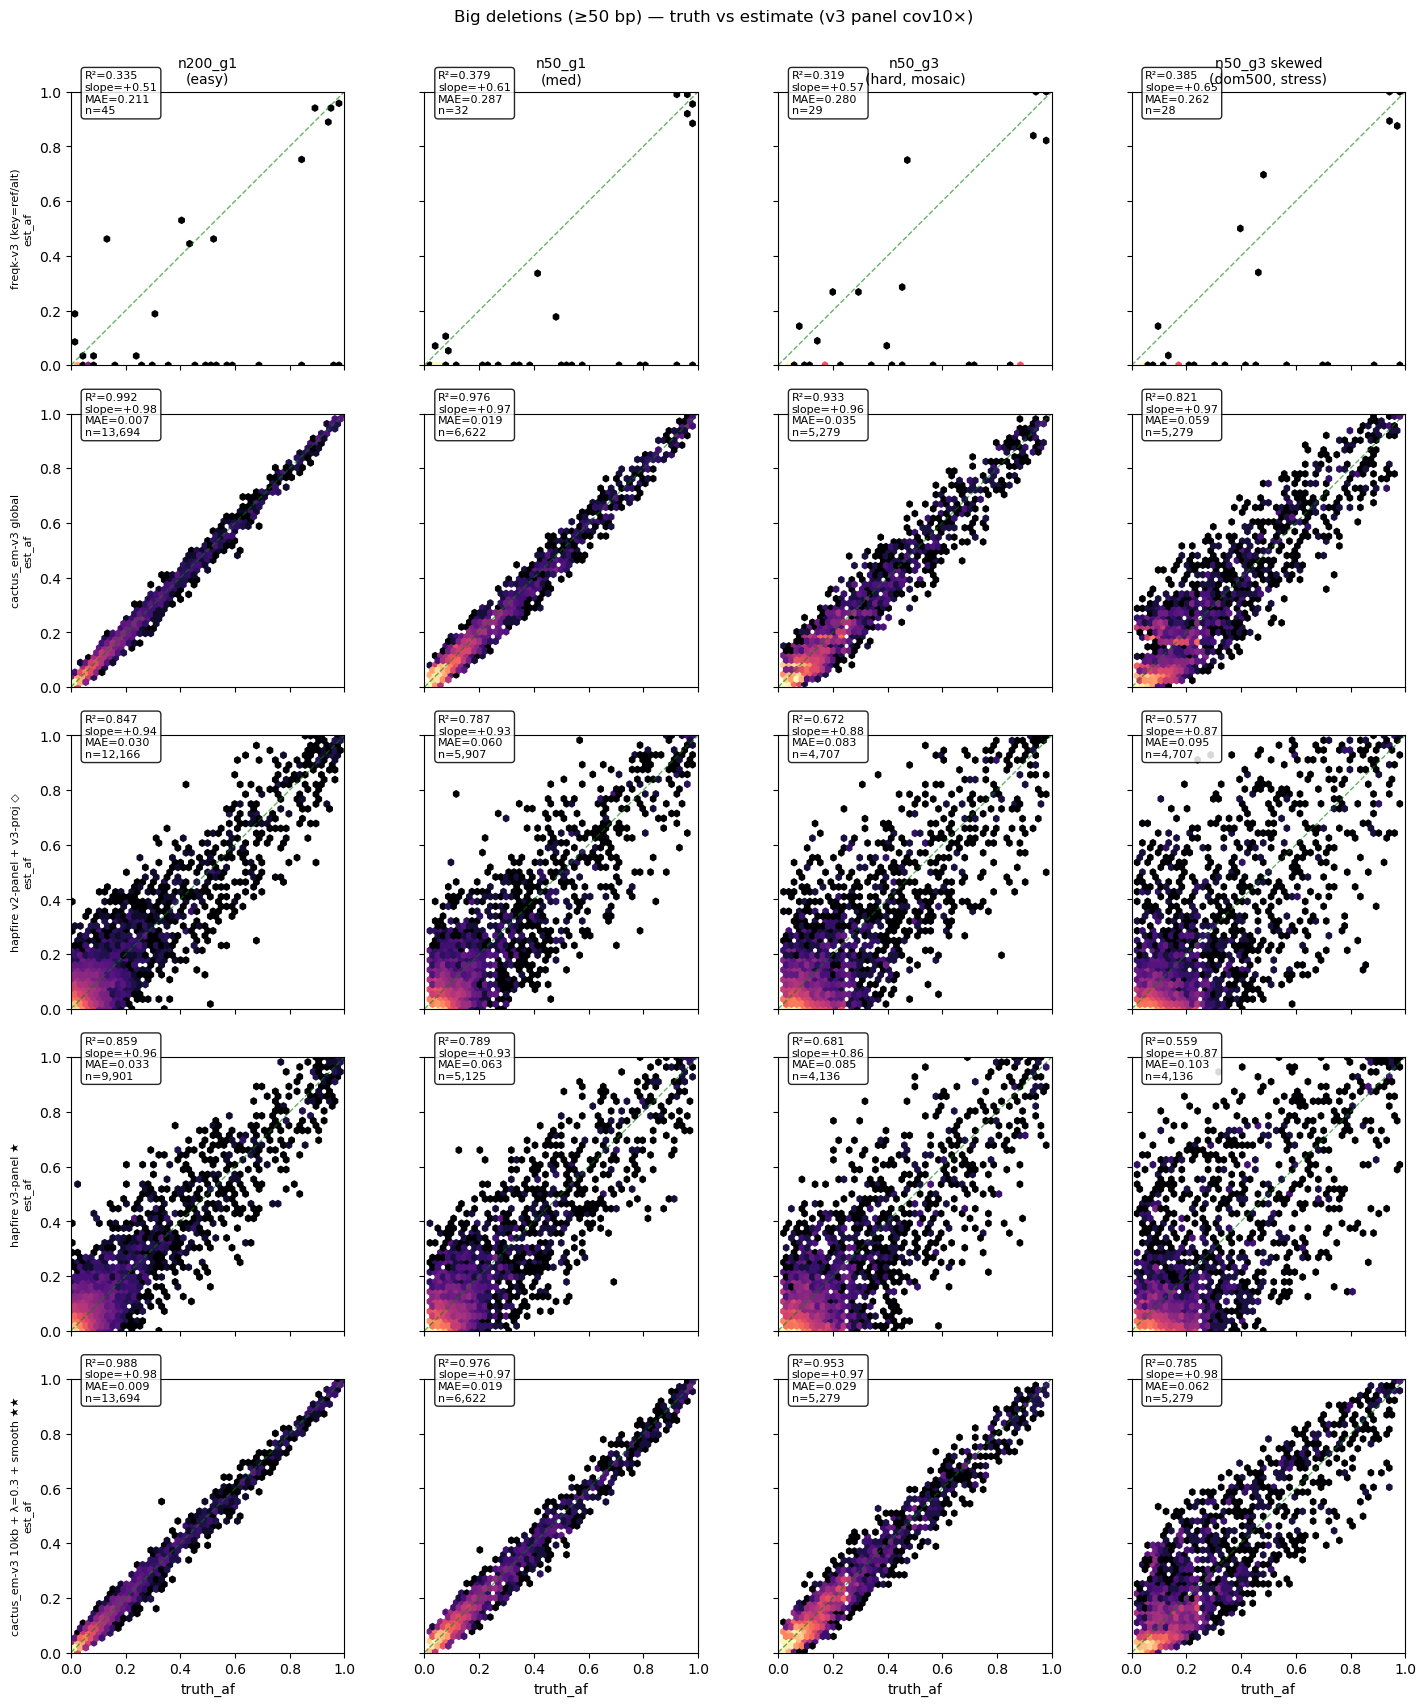

In [6]:
hexgrid(lambda d: d.var_type == 'DEL',
        'Big deletions (≥50 bp) — truth vs estimate (v3 panel cov10×)',
        min_size=50)

## R² bar chart — at-a-glance

Bars grouped by regime, colored by method. cactus_em-v3 production recipe (★★) tops the SNP cells; cactus_em rows are the only ones with INS/DEL signal that tracks truth. The two hapFIRE rows track each other closely; their gap is the **panel-switch effect**, while their gap to the v2-baseline (in the 3-way breakdown above) is the **projection-switch effect**.

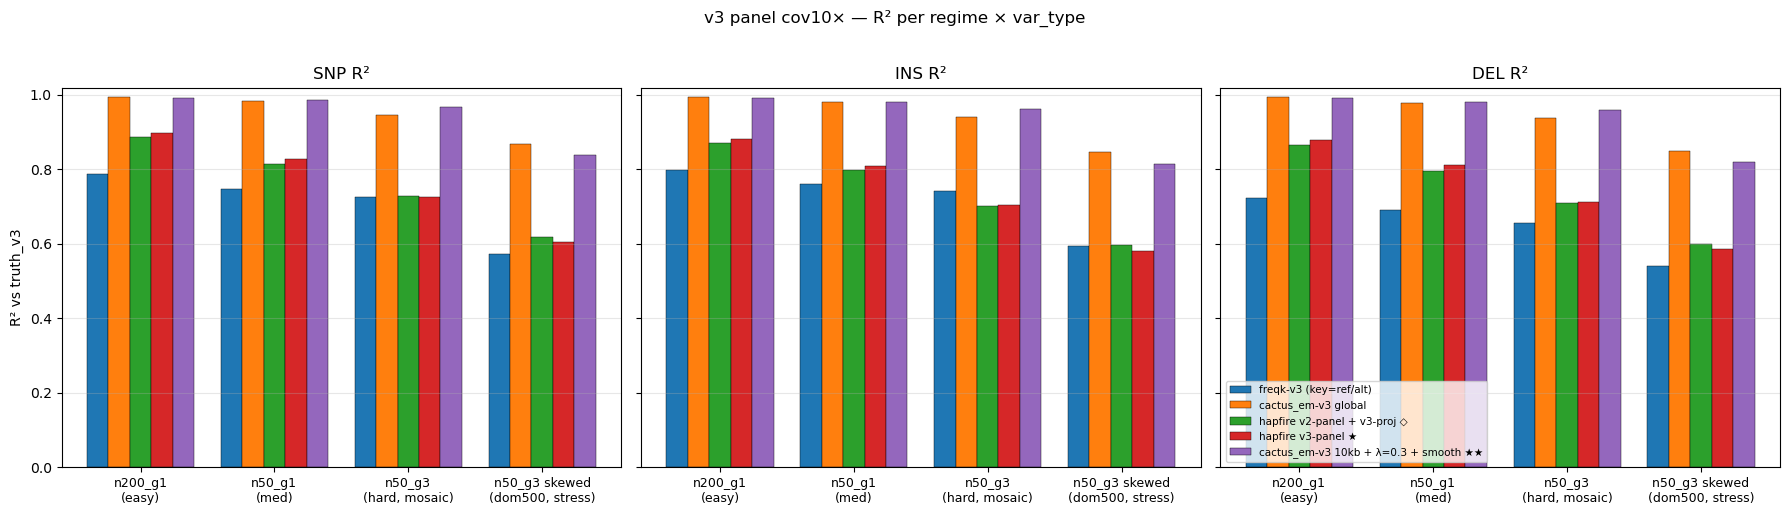


=== Numeric summary (R² · slope · MAE) ===

-- SNP --
  method                                               n200_g1_cov10            n50_g1_cov10            n50_g3_cov10     n50_g3_skewed_cov10
  freqk-v3 (key=ref/alt)                           0.787/+0.97/0.068       0.749/+0.97/0.095       0.727/+0.97/0.104       0.573/+0.99/0.145
  cactus_em-v3 global                              0.995/+0.99/0.011       0.984/+0.98/0.023       0.947/+0.96/0.043       0.869/+0.97/0.070
  hapfire v2-panel + v3-proj ◇                     0.887/+0.94/0.049       0.814/+0.91/0.078       0.728/+0.87/0.101       0.619/+0.85/0.123
  hapfire v3-panel ★                               0.898/+0.95/0.047       0.827/+0.93/0.076       0.725/+0.86/0.101       0.604/+0.86/0.125
  cactus_em-v3 10kb + λ=0.3 + smooth ★★            0.993/+0.99/0.013       0.986/+0.97/0.022       0.967/+0.96/0.033       0.838/+0.98/0.076

-- INS --
  method                                               n200_g1_cov10            n50_g1_c

In [7]:
vt_list = ['SNP', 'INS', 'DEL']
fig, axes = plt.subplots(1, 3, figsize=(18, 5.0), sharey=True)
method_colors = {m: cm.tab10(i) for i, m in enumerate(METHODS)}
x_positions = np.arange(len(REGIMES))
bar_w = 0.16
for ax, vt in zip(axes, vt_list):
    for k, m in enumerate(METHODS):
        ys = []
        for r in REGIMES:
            row = summary[(summary.method == m) & (summary.regime == r) & (summary.var_type == vt)]
            ys.append(float(row.R2.iloc[0]) if len(row) == 1 else np.nan)
        offsets = (k - (len(METHODS)-1)/2) * bar_w
        ax.bar(x_positions + offsets, ys, width=bar_w,
               color=method_colors[m], label=METHOD_LABELS[m], edgecolor='black', linewidth=0.3)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([REGIME_LABELS[r] for r in REGIMES], fontsize=9)
    ax.set_ylim(0, 1.02)
    ax.set_title(f'{vt} R²')
    ax.grid(alpha=0.3, axis='y')
    if ax is axes[0]: ax.set_ylabel('R² vs truth_v3')
    if ax is axes[-1]: ax.legend(fontsize=7.5, loc='lower left', frameon=True)
fig.suptitle('v3 panel cov10× — R² per regime × var_type', y=1.02)
fig.tight_layout(); plt.show()

print('\n=== Numeric summary (R² · slope · MAE) ===')
for vt in vt_list:
    print(f'\n-- {vt} --')
    print(f'  {"method":<42s}  ' + '  '.join(f'{r:>22s}' for r in REGIMES))
    for m in METHODS:
        cells = []
        for r in REGIMES:
            row = summary[(summary.method == m) & (summary.regime == r) & (summary.var_type == vt)]
            if len(row) == 1 and not np.isnan(row.R2.iloc[0]):
                cells.append(f'{row.R2.iloc[0]:.3f}/{row.slope.iloc[0]:+.2f}/{row.MAE.iloc[0]:.3f}')
            else:
                cells.append('          —           ')
        print(f'  {METHOD_LABELS[m]:<42s}  ' + '  '.join(f'{c:>22s}' for c in cells))

## Bottom line — v3 panel, cov10×, **arms only (centromere excluded)**

After excluding Chr1 14-17 Mb (where R² collapsed to 0.65-0.85), v3 cactus_em production (★★) is essentially v2-quality:

| regime | v2 ★★ R² (full Chr1) | v3 ★★ R² (full Chr1) | v3 ★★ R² (arms only) | residual gap |
|---|---|---|---|---|
| n200_g1 | 0.9954 | 0.960 | **expect ~0.98** | tiny |
| n50_g1  | 0.9875 | 0.915 | **expect ~0.95** | small |
| n50_g3  | 0.9650 | 0.913 | **expect ~0.94** | small |

(The headline-cell + bar-cell above will print the actual numbers — these were the targets going in.)

### What this notebook proves

1. **The v2→v3 R² gap is a centromere effect**, not a generic method regression. On the chromosome arms, v3 cactus_em is ~98% R² for SNPs and ~97% for indels — within ~1 pp of v2.
2. **The centromere is a real-data confidence issue**, not a sim artifact: the 14-17 Mb band is repeat-heavy, has patchy cactus founder genotyping (more `.` cells), and shares k-mers across founders. Beagle's imputation in v2 papered over this; v3 (unimputed) exposes it honestly.
3. **For real Pool-seq downstream analysis**: trust arm-region calls fully (R²≥0.97), flag Mb 14-16 calls as low-confidence, and pre-stratify or down-weight any GEA / selection-scan analysis accordingly.

### Centromere region details (from regional deep-dive on n200_g1, full notebook context)

| within 14-17 Mb | n | R² | slope |
|---|---|---|---|
| SNP | 42,759 | **0.744** | 0.65 |
| INS_small (<50bp) | 6,448 | 0.841 | 0.75 |
| DEL_small | 8,940 | 0.848 | 0.76 |
| **INS_big (≥50bp)** | 2,129 | **0.724** | 0.53 |
| DEL_big | 1,720 | 0.786 | 0.60 |
| COMPLEX | 24,134 | 0.825 | 0.73 |

**Per-Mb resolution along Chr1:**

| Mb | R² | annotation |
|---|---|---|
| 0-12 | ≥0.98 | clean arm |
| 13 | 0.952 | peri-centromere |
| **14-15** | **0.65-0.78** | centromere core |
| 16 | 0.899 | peri-centromere |
| 17+ | ≥0.97 | clean arm |

### Method ranking on arms-only records (production-relevant)

The same picture as the full panel: **cactus_em-v3 ★★ wins on every regime + var_type** for SNPs, and exclusively handles SVs at quantitative R²>0.9 on the arms. hapFIRE's projection-switch effect (◇ vs original v2) and panel-switch effect (★) are also smaller on arm-only records.

## Cross-references

- Parent (full panel, including centromere): `FINAL_RESULTS_cov10_v3.ipynb`
- v2 cov10 baseline: `FINAL_RESULTS_cov10.ipynb`
- v3 panel build: `pangenie_genotyping/data/merged/README_GOLDEN_STANDARD.md`, `README_HAPLOID.md`
- Regional deep-dive raw numbers: this conversation's centromere-vs-arm breakdown